<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Vertibral_Spine_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [50]:
df = pd.read_csv('Dataset_spine.csv')
df.head(11)

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal
5,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Abnormal
6,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Abnormal
7,45.366754,10.755611,29.038349,34.611142,117.270067,-10.675871,Abnormal
8,43.790190,13.533753,42.690814,30.256437,125.002893,13.289018,Abnormal
9,36.686353,5.010884,41.948751,31.675469,84.241415,0.664437,Abnormal


In [51]:
df.tail(11)

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
299,82.905351,29.894119,58.250542,53.011232,110.708958,6.079338,Normal
300,50.676677,6.461501,35.000000,44.215175,116.587970,-0.214711,Normal
301,89.014875,26.075981,69.021259,62.938894,111.481075,6.061508,Normal
302,54.600316,21.488974,29.360216,33.111342,118.343321,-1.471067,Normal
303,34.382299,2.062683,32.390820,32.319617,128.300199,-3.365516,Normal
304,45.075450,12.306951,44.583177,32.768499,147.894637,-8.941709,Normal
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal


In [52]:
df.shape

(310, 7)

In [53]:
df.columns

Index(['pelvic incidence', ' pelvic tilt', ' lumbar lordosis angle',
       ' sacral slope', ' pelvic radius', ' grade of spondylolisthesis',
       'Class_att'],
      dtype='object')

In [54]:
df.dtypes

,0
pelvic incidence,float64
pelvic tilt,float64
lumbar lordosis angle,float64
sacral slope,float64
pelvic radius,float64
grade of spondylolisthesis,float64
Class_att,object


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   pelvic incidence             310 non-null    float64
 1    pelvic tilt                 310 non-null    float64
 2    lumbar lordosis angle       310 non-null    float64
 3    sacral slope                310 non-null    float64
 4    pelvic radius               310 non-null    float64
 5    grade of spondylolisthesis  310 non-null    float64
 6   Class_att                    310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


In [56]:
df.describe(include = 'all')

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310
unique,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,Abnormal
freq,NaN,NaN,NaN,NaN,NaN,NaN,210
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694,NaN
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027,NaN
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179,NaN
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727,NaN
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934,NaN
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352,NaN


In [57]:
df.isnull().sum()

,0
pelvic incidence,0
pelvic tilt,0
lumbar lordosis angle,0
sacral slope,0
pelvic radius,0
grade of spondylolisthesis,0
Class_att,0


In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
# Dropping Object column:

df = df.drop('Class_att', axis=1)

# Handling Outliers

In [60]:
Q1 = df['pelvic incidence'].quantile(0.25)
Q3 = df['pelvic incidence'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['pelvic incidence'] >= lower_bound) & (df['pelvic incidence'] <= upper_bound)].copy()

print('Before removing outliers:', len(df))
print('After removing outliers:', len(df_outliers))

Before removing outliers: 310
After removing outliers: 307


# Univariate Analysis

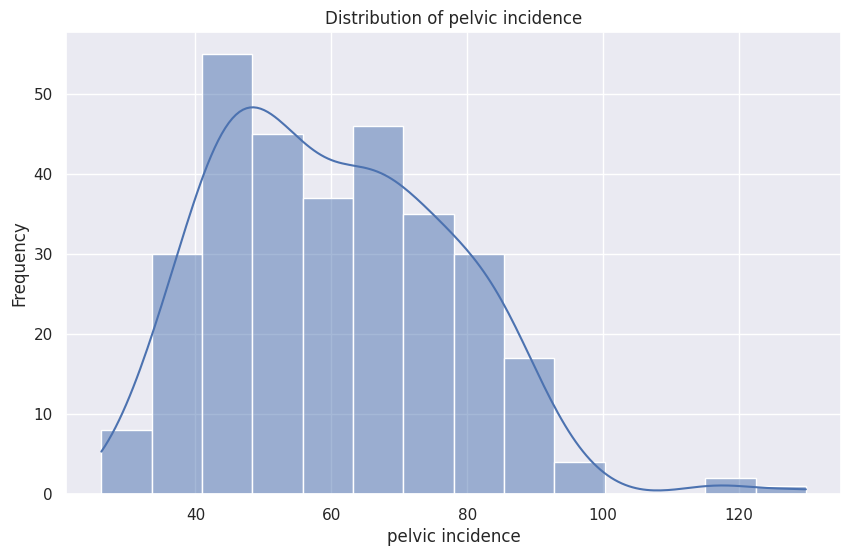

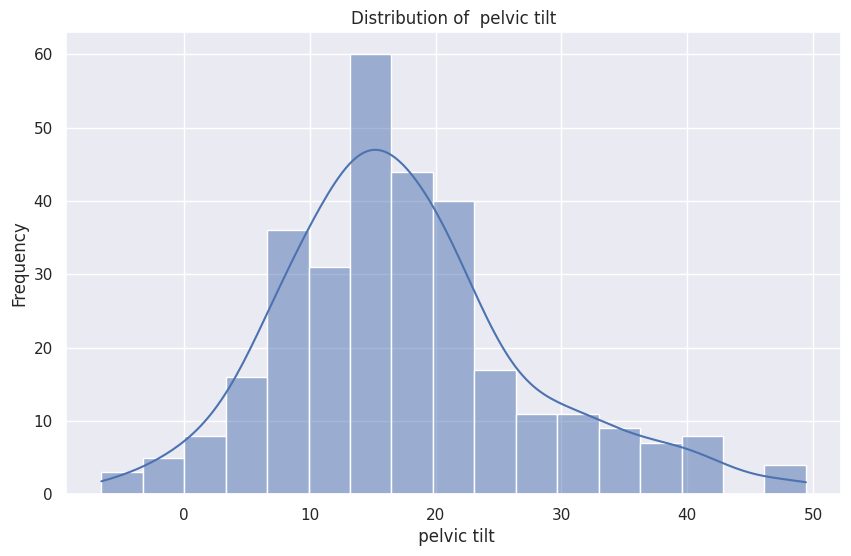

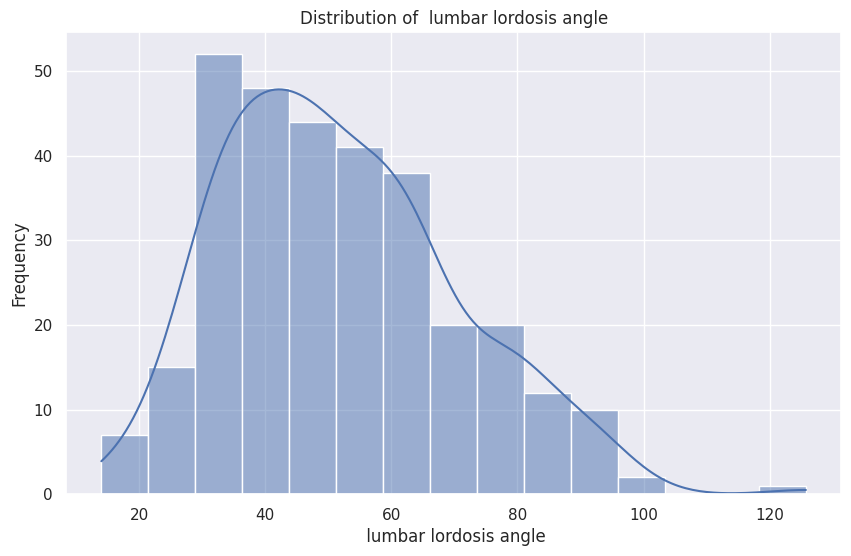

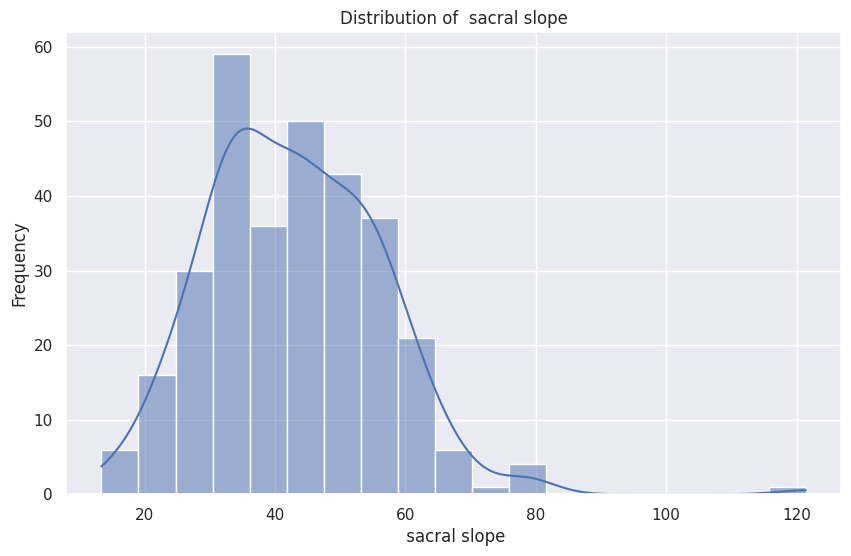

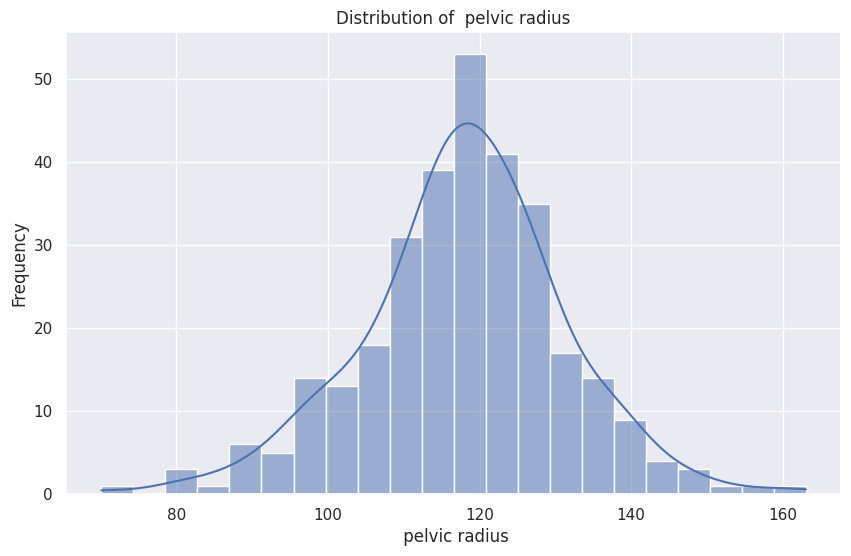

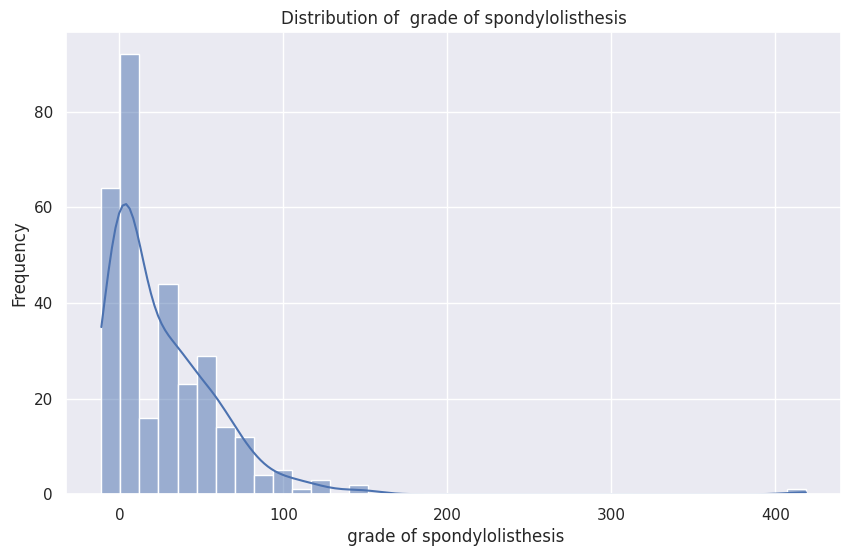

In [61]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

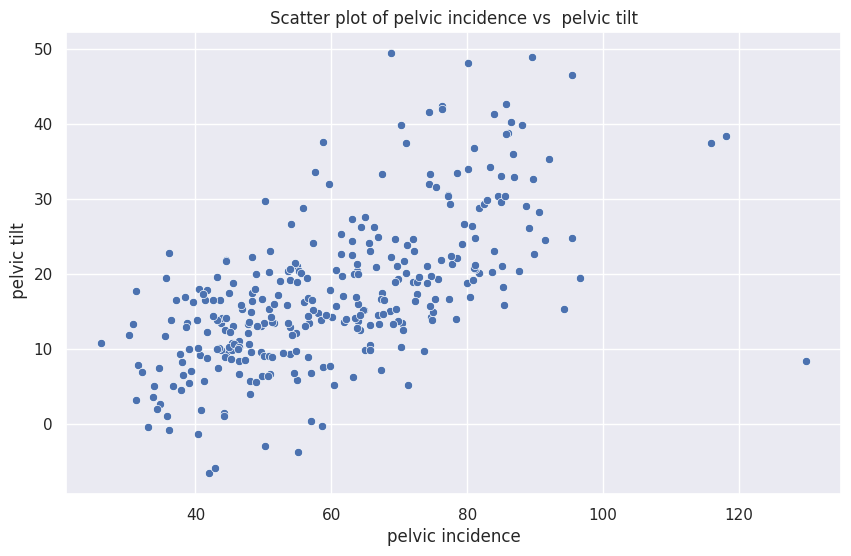

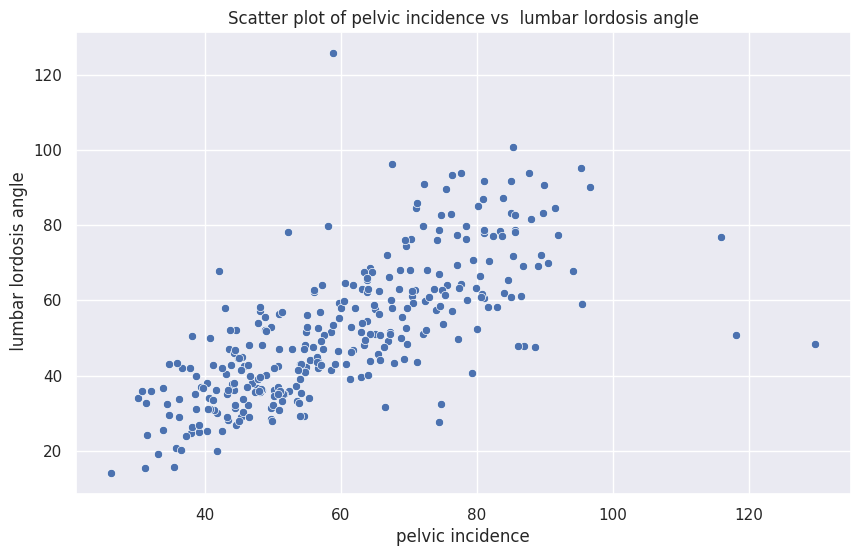

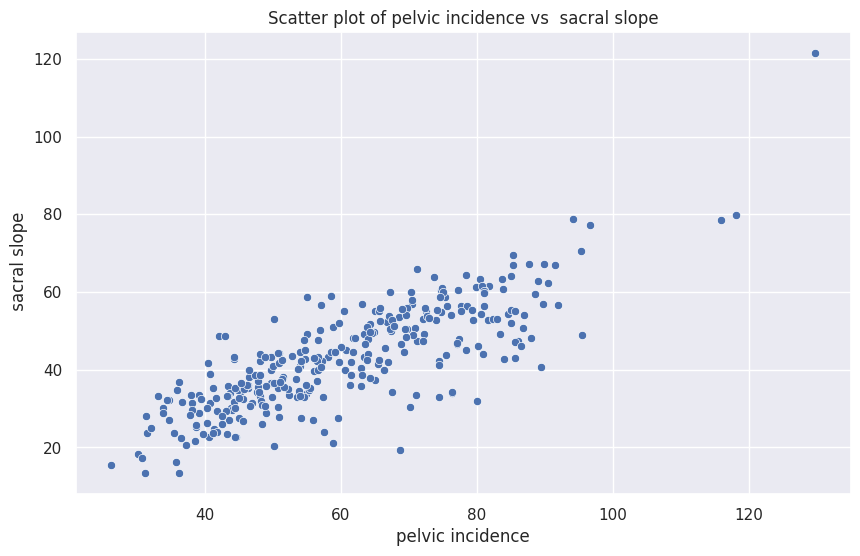

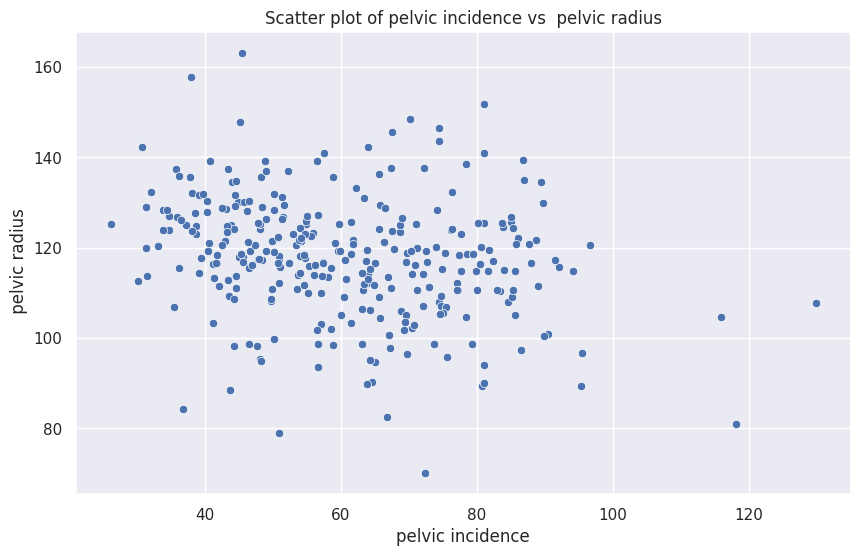

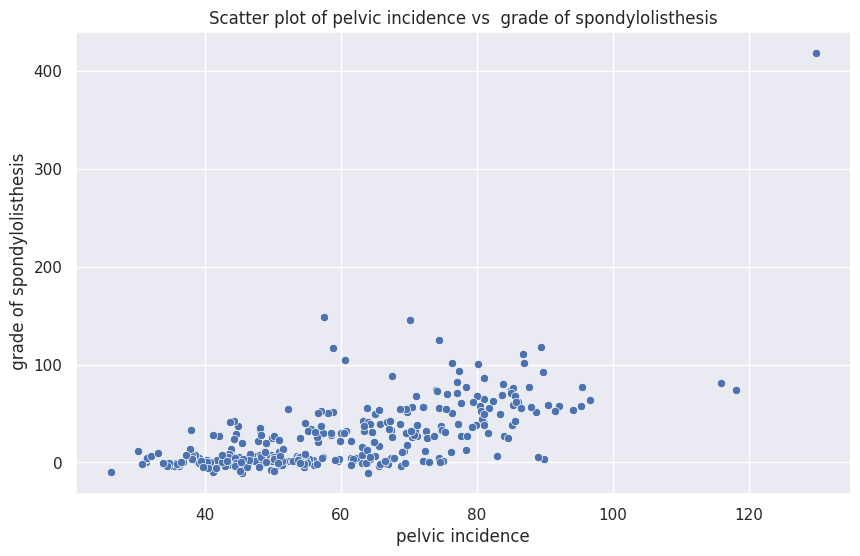

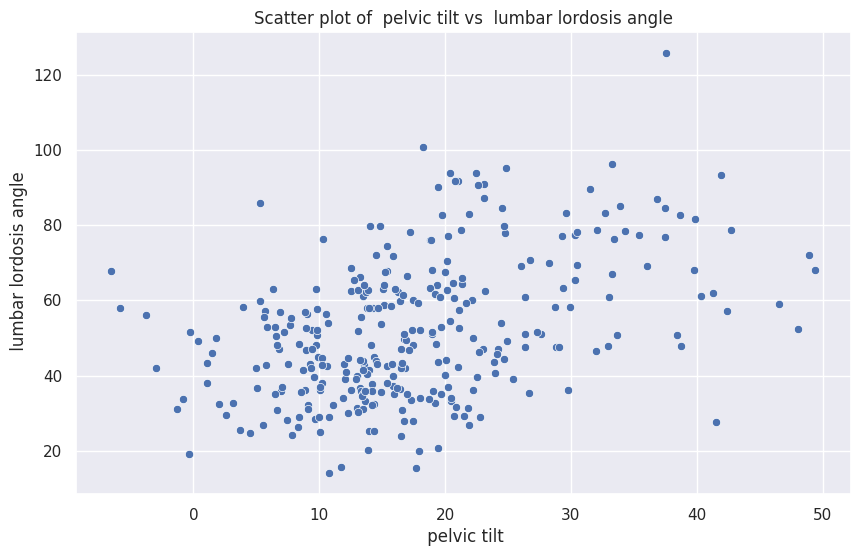

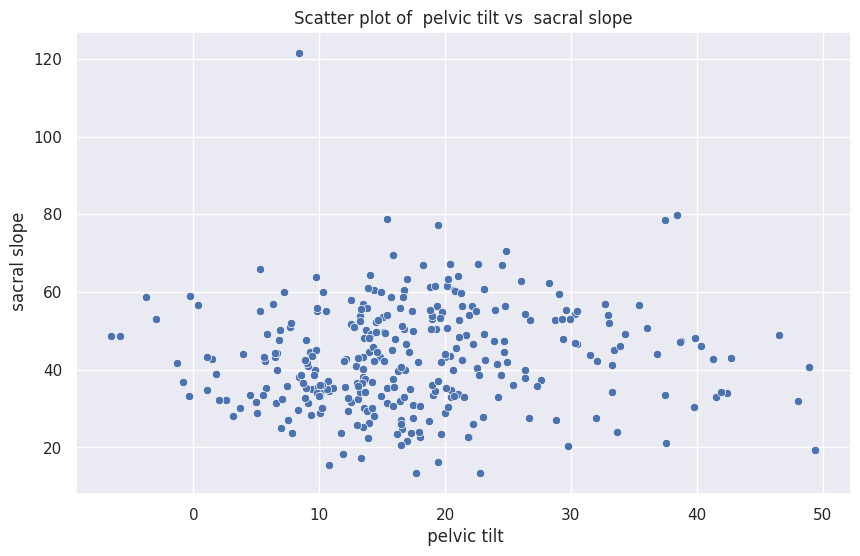

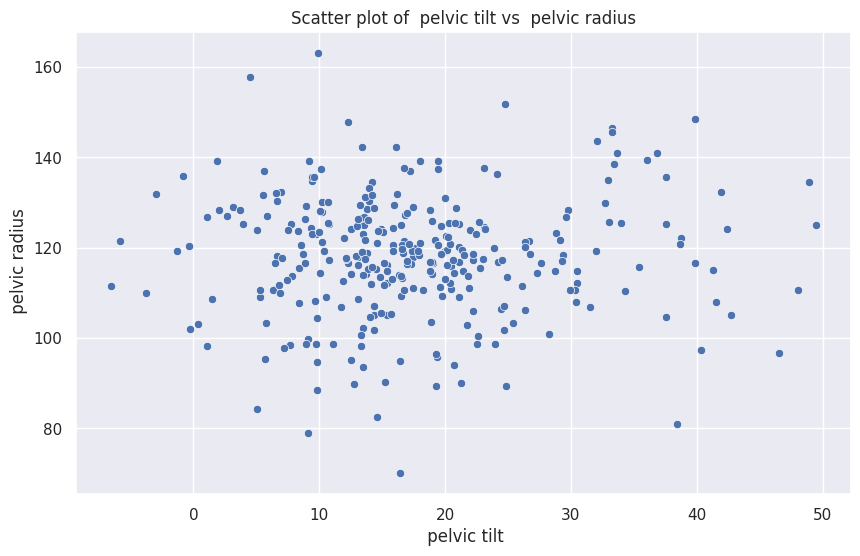

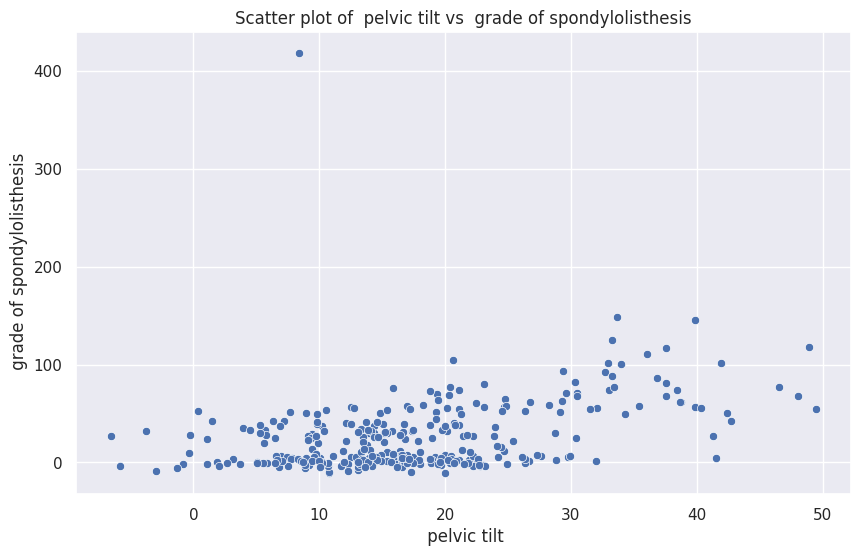

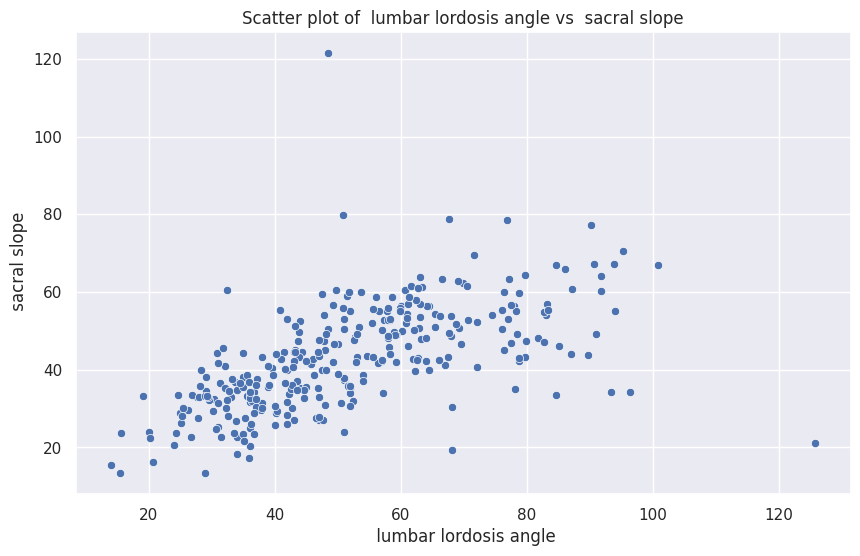

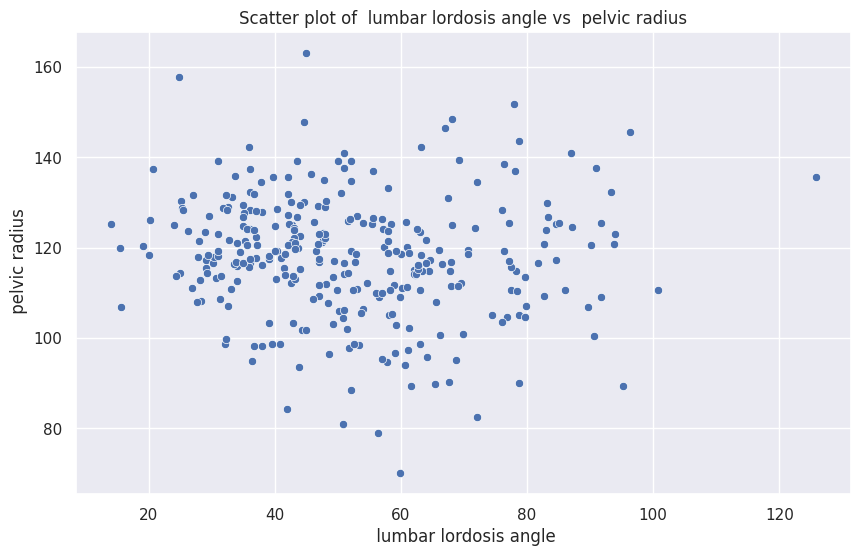

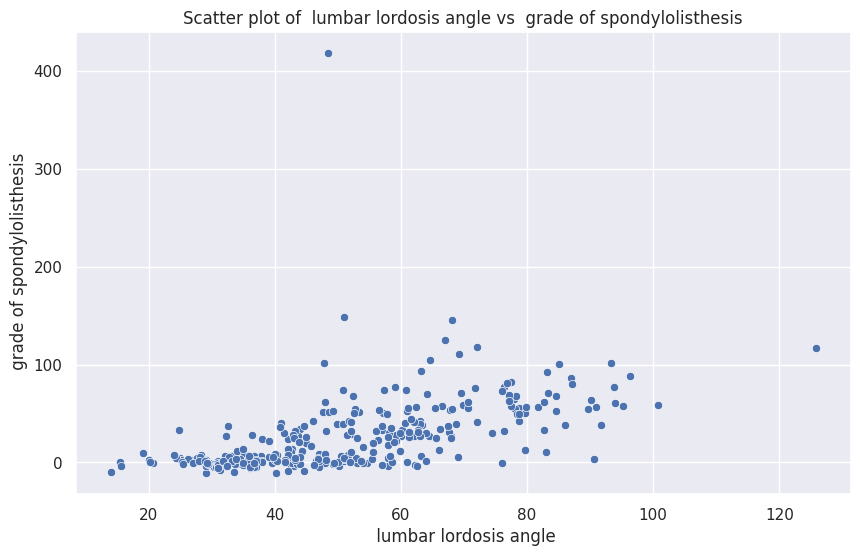

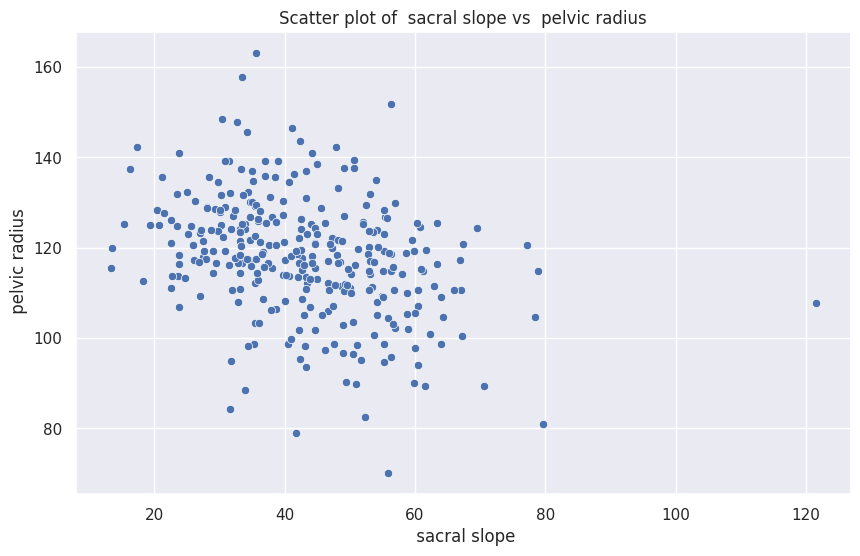

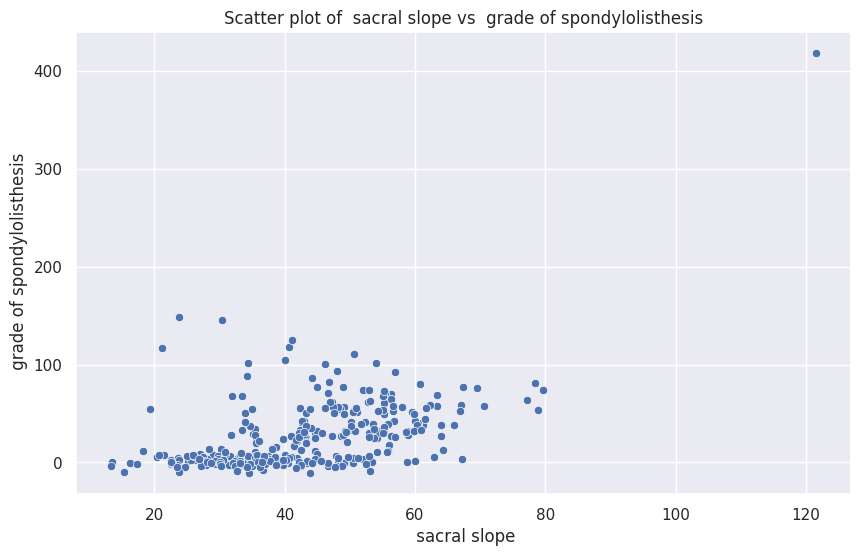

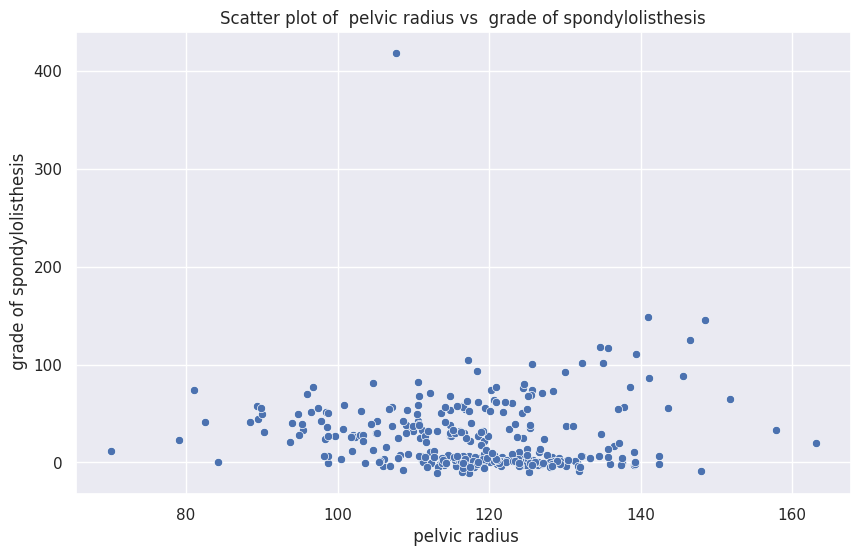

In [62]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

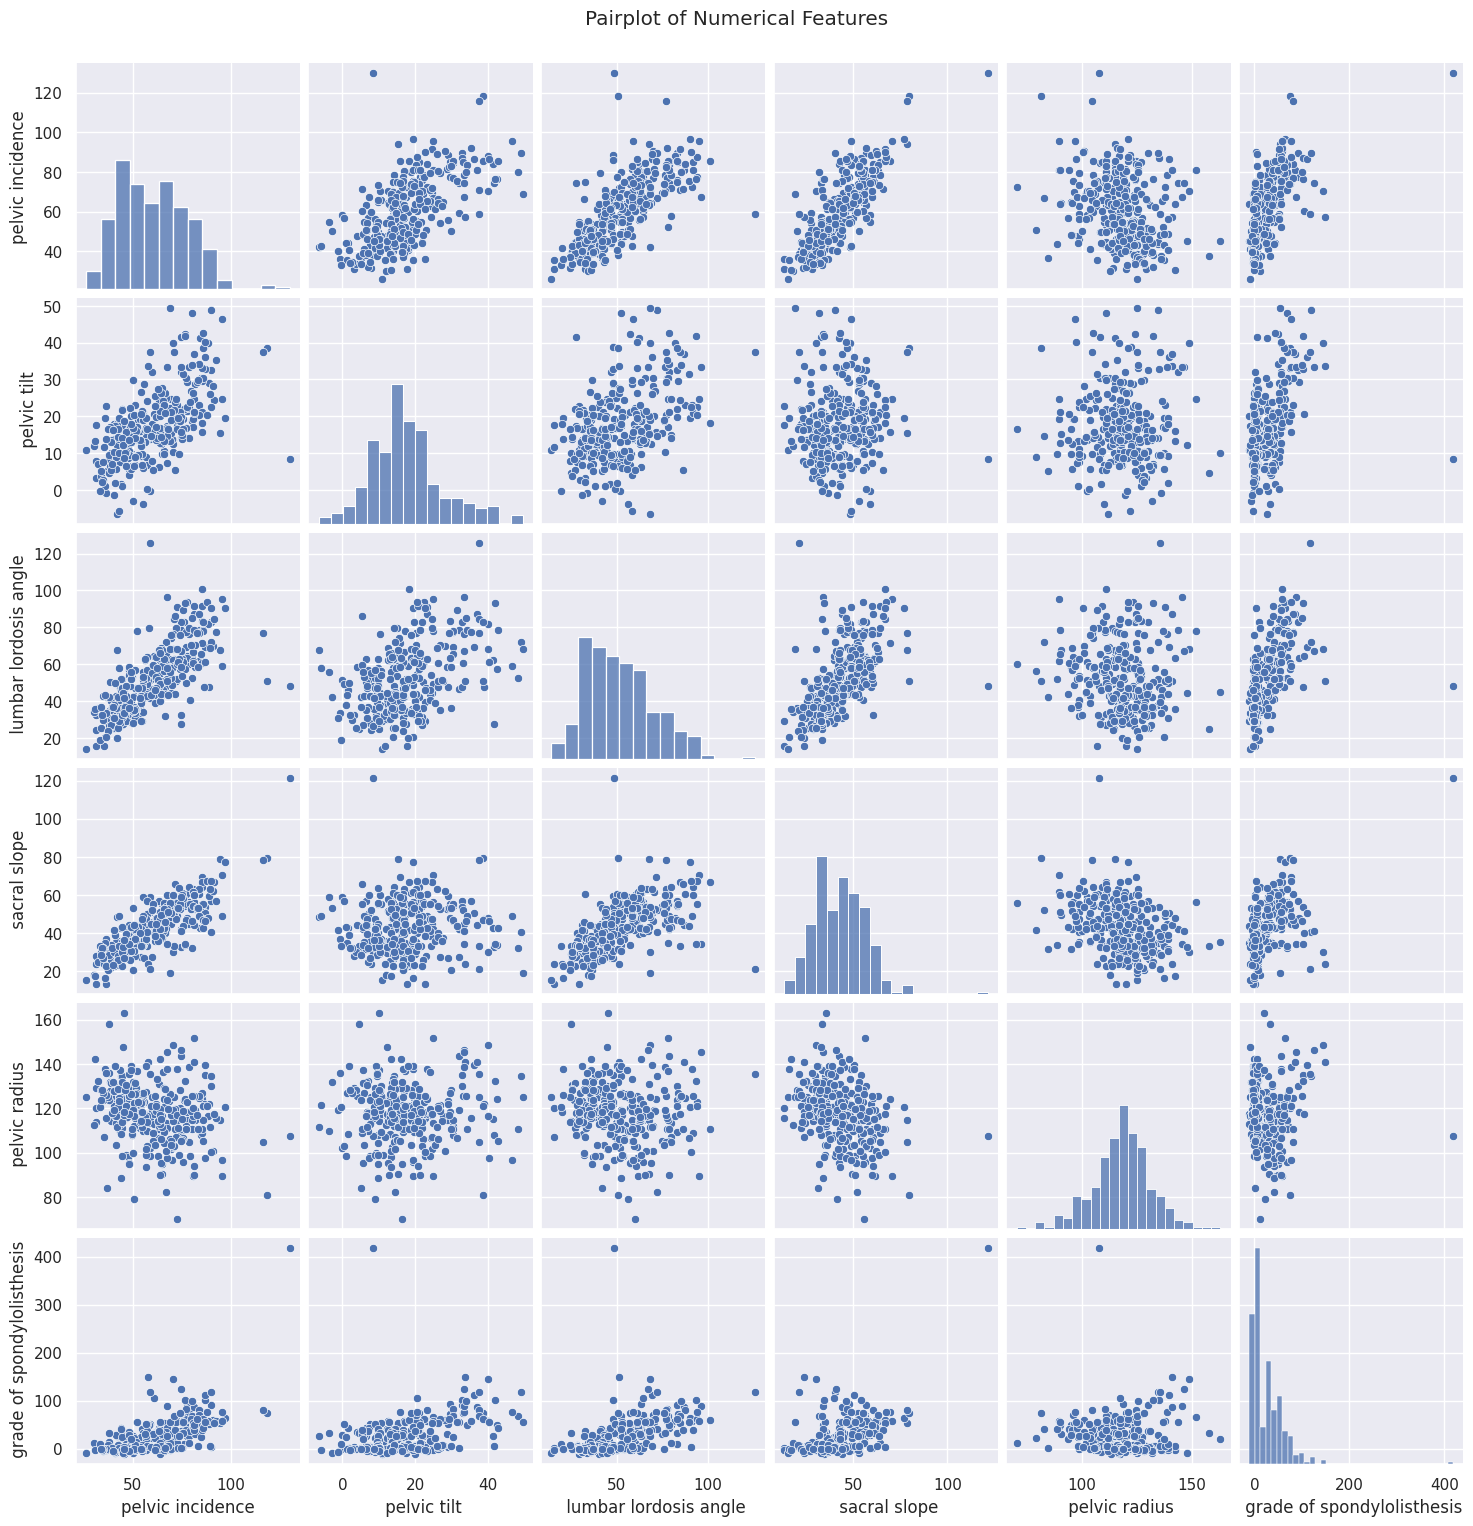

In [63]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

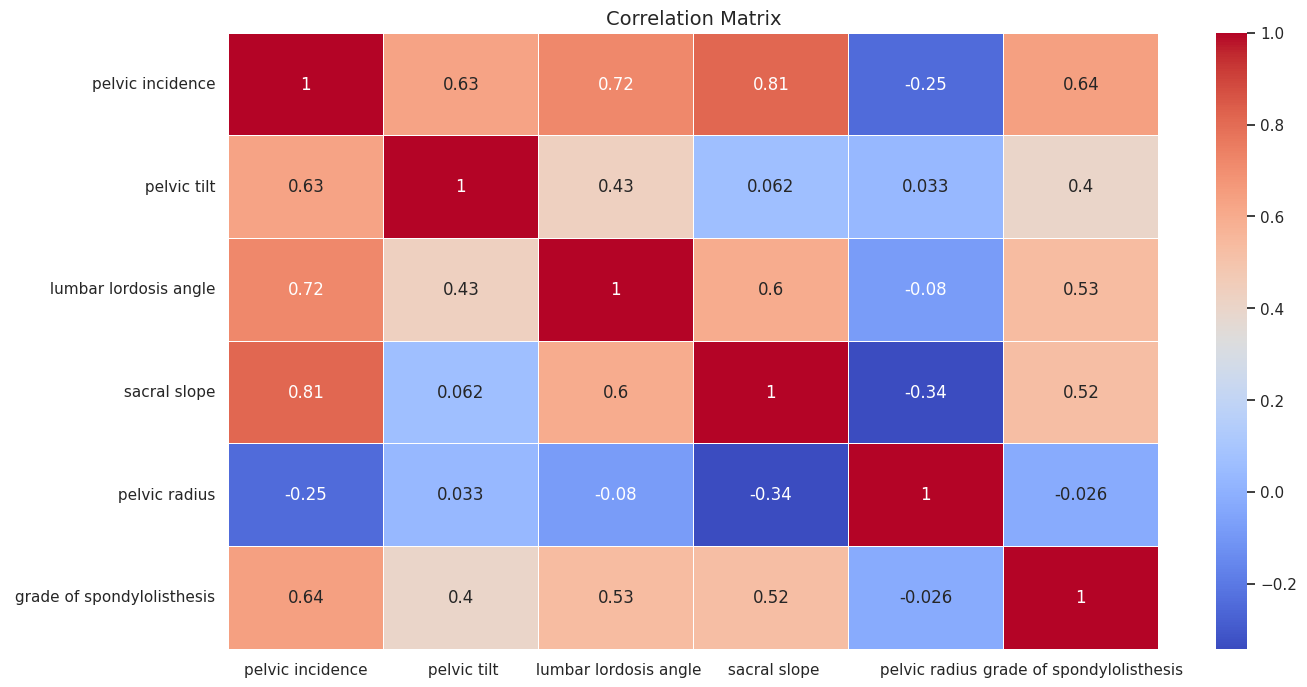

In [64]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Machine Learning

In [65]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [66]:
X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values

In [67]:
print(X)

[[ 63.0278175   22.55258597  39.60911701  40.47523153  98.67291675]
 [ 39.05695098  10.06099147  25.01537822  28.99595951 114.4054254 ]
 [ 68.83202098  22.21848205  50.09219357  46.61353893 105.9851355 ]
 ...
 [ 61.44659663  22.6949683   46.17034732  38.75162833 125.6707246 ]
 [ 45.25279209   8.69315736  41.5831264   36.55963472 118.5458418 ]
 [ 33.84164075   5.07399141  36.64123294  28.76764934 123.9452436 ]]


In [68]:
print(Y)

[-2.54399986e-01  4.56425864e+00 -3.53031731e+00  1.12115234e+01
  7.91850062e+00  2.23065173e+00  5.98855070e+00 -1.06758708e+01
  1.32890182e+01  6.64437117e-01 -7.82598575e+00  4.99751446e-01
  8.02889463e+00  7.04480294e+00  5.76694694e+00  5.41582514e+00
 -6.22526643e-01  3.62302007e+00  1.42918576e+00 -1.24440249e+00
  6.45164764e+00  2.43256144e+00  1.57796968e+01 -4.98712962e+00
 -3.23756249e+00  1.57120482e+00 -1.00931082e+01  8.99281573e+00
  2.65232064e+00 -2.00589175e+00  1.08695655e+01  6.38683165e+00
  5.56961959e+00  2.70300805e+00  1.47428584e+00  4.39308050e+00
  6.41342771e+00 -2.63489651e-01  2.81242686e+00  1.69470510e+00
 -3.46035799e+00  2.04547580e+00  5.32984320e+00 -7.99624469e-01
 -2.32568384e+00 -2.52670151e+00  6.48170910e+00 -4.49795756e+00
 -1.53738307e+00  2.06296255e+00  3.55837236e+00  5.00008879e+00
  5.74061408e+00  1.14632233e+01 -9.56924986e+00  6.27301217e+00
  5.75327746e+00  1.66270559e+00 -2.91907595e+00  7.94790486e+00
  5.61259060e+01  9.20272

# Handling Missing Values

In [69]:
imputer = SimpleImputer(missing_values=np.nan, strategy = 'mean')
imputer.fit(X[:, 1:3])
X[:, 1:3] = imputer.transform(X[:, 1:3])

In [70]:
print(X)

[[ 63.0278175   22.55258597  39.60911701  40.47523153  98.67291675]
 [ 39.05695098  10.06099147  25.01537822  28.99595951 114.4054254 ]
 [ 68.83202098  22.21848205  50.09219357  46.61353893 105.9851355 ]
 ...
 [ 61.44659663  22.6949683   46.17034732  38.75162833 125.6707246 ]
 [ 45.25279209   8.69315736  41.5831264   36.55963472 118.5458418 ]
 [ 33.84164075   5.07399141  36.64123294  28.76764934 123.9452436 ]]


In [71]:
le = LabelEncoder()
le.fit_transform(Y)
y = le.fit_transform(Y)

In [72]:
print(y)

[ 55 108  18 153 141  89 125   1 158  65   6  62 144 137 123 119  46 105
  73  40 133  91 161  10  23  76   2 146  93  32 152 131 120  94  74 107
 132  54  96  80  19  87 117  43  29  27 134  12  38  88 104 114 121 154
   3 128 122  79  25 142 260 297 192 183 149 181 187 281  71 190 205 301
 286 214 263 307 303 246 209 168 282 287 247 276 242 165 170 219 173 185
 198 206 288 243 251 308 275 211 270 196 175 224 178 176 298 136 241 290
 235 227 232 283 186 245 295 309 264 273 162 202 229 292 277 252 218 208
 189 266 268 228 182 163 254 257 255 294 262 240 261 221 193 305 269 302
 197 237 279 203 225 216 230 215 204 195 188 233 271 236 248 226 267 234
 285 293 174 280 217 155 265 172 167 157 166 171 169 244 213 238 249 253
 212 200 256 278 222 250 239 194 272 274 231 258 306 207 177 223 259 304
 210 201 220 296 300 184 179 299 291 284 289 191 143  86 113  42  20  33
  41 130  70 101  53  45 199  49  98 103 129 109 106  24  15 116  69  28
 159   0  72 111 151  35   8 160  44  16 139  51 14

# Spliting data into training and testing

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [74]:
print(X_train)

[[ 61.44659663  22.6949683   46.17034732  38.75162833 125.6707246 ]
 [ 63.0278175   22.55258597  39.60911701  40.47523153  98.67291675]
 [ 69.62628302  21.12275138  52.76659472  48.50353164 116.8030913 ]
 ...
 [ 84.97413208  33.02117462  60.85987263  51.95295747 125.6595336 ]
 [ 63.92947003  19.97109671  40.17704963  43.95837332 113.0659387 ]
 [ 35.70345781  19.44325311  20.7         16.26020471 137.5406125 ]]


In [75]:
print(X_test)

[[ 67.41253785  17.44279712  60.14464036  49.96974073 111.12397   ]
 [ 63.02630005  27.33624023  51.60501665  35.69005983 114.5066078 ]
 [ 91.46874146  24.50817744  84.62027202  66.96056402 117.3078968 ]
 [ 72.56070163  17.38519079  51.99999999  55.17551084 119.1937238 ]
 [ 54.74177518  12.09507205  40.99999999  42.64670314 117.6432188 ]
 [ 70.39930842  13.46998624  61.19999999  56.92932218 102.3375244 ]
 [ 33.84164075   5.07399141  36.64123294  28.76764934 123.9452436 ]
 [ 72.05403412  24.70073725  79.87401586  47.35329687 107.1723576 ]
 [ 84.99895554  29.61009772  83.35219438  55.38885782 126.9129899 ]
 [ 69.3988184   18.89840693  75.96636144  50.50041147 103.5825398 ]
 [ 65.61180231  23.13791922  62.58217893  42.47388309 124.1280012 ]
 [ 45.25279209   8.69315736  41.5831264   36.55963472 118.5458418 ]
 [ 43.20318499  19.66314572  35.          23.54003927 124.8461088 ]
 [ 48.10923638  14.93072472  35.56468278  33.17851166 124.0564518 ]
 [ 50.67667667   6.46150127  35.          44.215

In [76]:
print(y_train)

[ 26  55 254 289 192 238 200 174 248 198 244 103   9  80 282 166 177  48
 105 290 293  77 117 308 221 273  89  78  96  61 186 281  63 277  74 304
 106  58 252 130  17  84  40 123 206  53 272  29  75 241 236 226 235 138
  87 168 164 230 157 208 163 196 140 158  90  28  93 131 128 120  66  38
  52 306  94 107  98 183 151  85 187 234 203  21  11  51  12  59  47  19
  91 224 190 154 240  23 145 255 199 264 169 269 156 172  24 122 297 194
 274 242  92 295 127  36 222 162  45 167 237   4  30   3 213  34  67 113
 256 159 270  70 182 211 100 247 179 260 251 207 193 147 225 300 204 150
 294 287 218  10   6 137 275 143  79 115  27 109 176 132   7 133  81 116
 307 220   8 148  14 216 101  37  18 210  42 121 125 299 268 112 246 245
 181 278 215  95 267 134 231 263 288  16 201  83 219  35 302 262 217 276
 233 189 223  99 298 195 129  76 259 149 119 227   2 303  43 153  88 126
 152 292 309  64  41  13 191 108 161   1 305 170 160  33  71 104 271  22
  68  82 249 124 111 301 228 197 257 184 180 286   

In [77]:
print( y_test)

[209 139 250 205 229 178  57 261 283  49  15  60  25 142  56 175  39 110
  69 173 212  72  73 155  62 284 265 296 165 258 280  20   5 144 146 239
  32 102 232 188  44  86 243 118 171 202  31  50 285 135 136  97 141 253
 185 114 214 279  65 266  46 291]


# Feature Scalling

In [78]:
sc = StandardScaler()
X_train[:, 3:] = sc.fit_transform(X_train[:, 3:]) # [:, 3:] => Taking column Age and Salary
X_test[:, 3:] = sc.transform(X_test[:, 3:])

In [79]:
print(X_train)

[[ 6.14465966e+01  2.26949683e+01  4.61703473e+01 -3.15612193e-01
   5.92944488e-01]
 [ 6.30278175e+01  2.25525860e+01  3.96091170e+01 -1.88797860e-01
  -1.58014878e+00]
 [ 6.96262830e+01  2.11227514e+01  5.27665947e+01  4.01885378e-01
  -1.20824359e-01]
 ...
 [ 8.49741321e+01  3.30211746e+01  6.08598726e+01  6.55677338e-01
   5.92043708e-01]
 [ 6.39294700e+01  1.99710967e+01  4.01770496e+01  6.74747559e-02
  -4.21633268e-01]
 [ 3.57034578e+01  1.94432531e+01  2.07000000e+01 -1.97042165e+00
   1.54836922e+00]]


In [80]:
print(X_test)

[[ 6.74125379e+01  1.74427971e+01  6.01446404e+01  5.09761905e-01
  -5.77945185e-01]
 [ 6.30263001e+01  2.73362402e+01  5.16050167e+01 -5.40867498e-01
  -3.05671694e-01]
 [ 9.14687415e+01  2.45081774e+01  8.46202720e+01  1.75986397e+00
  -8.01918217e-02]
 [ 7.25607016e+01  1.73851908e+01  5.20000000e+01  8.92777126e-01
   7.16011673e-02]
 [ 5.47417752e+01  1.20950721e+01  4.10000000e+01 -2.90315504e-02
  -5.32012607e-02]
 [ 7.03993084e+01  1.34699862e+01  6.12000000e+01  1.02181403e+00
  -1.28517912e+00]
 [ 3.38416408e+01  5.07399141e+00  3.66412329e+01 -1.05018476e+00
   4.54057985e-01]
 [ 7.20540341e+01  2.47007372e+01  7.98740159e+01  3.17256703e-01
  -8.96016280e-01]
 [ 8.49989555e+01  2.96100977e+01  8.33521944e+01  9.08474158e-01
   6.92936249e-01]
 [ 6.93988184e+01  1.88984069e+01  7.59663614e+01  5.48806074e-01
  -1.18496599e+00]
 [ 6.56118023e+01  2.31379192e+01  6.25821789e+01 -4.17468083e-02
   4.68768413e-01]
 [ 4.52527921e+01  8.69315736e+00  4.15831264e+01 -4.76888411e-01

# Regression

# Simple Linear Regression

In [81]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [83]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [85]:
y_pred = regressor.predict(X_test)

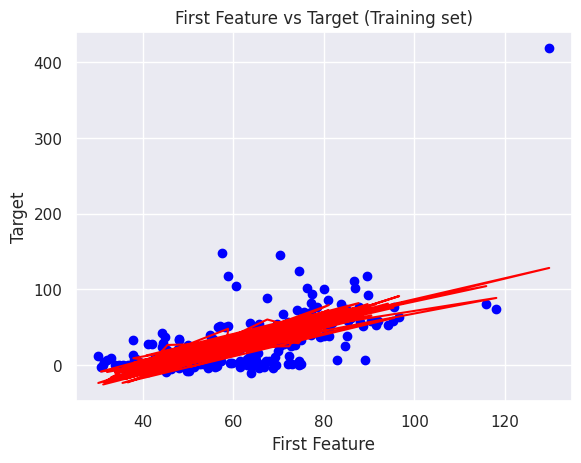

In [88]:
plt.scatter(X_train[:, 0], y_train, color = 'blue')
plt.plot(X_train[:, 0], regressor.predict(X_train), color = 'red')
plt.title('First Feature vs Target (Training set)')
plt.xlabel('First Feature')
plt.ylabel('Target')
plt.show()

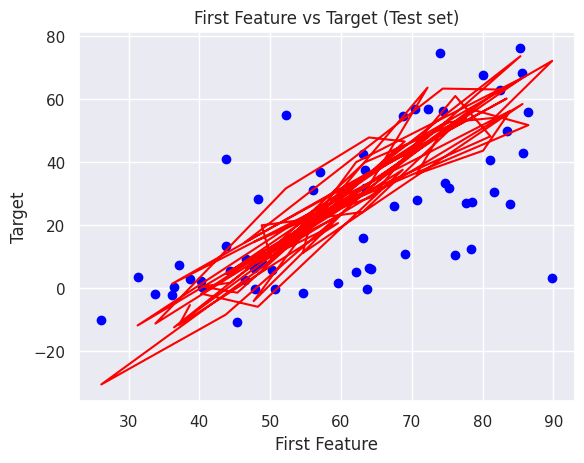

In [90]:
plt.scatter(X_test[:, 0], y_test, color = 'blue')
plt.plot(X_test[:, 0], y_pred, color = 'red')
plt.title('First Feature vs Target (Test set)')
plt.xlabel('First Feature')
plt.ylabel('Target')
plt.show()

# Thank you